In [1]:
import mediapipe as mp
import numpy as np
import cv2
from IPython.display import Image
import matplotlib.pyplot as plt
%matplotlib inline

In [1]:
mp_hands = mp.tasks.vision.HandLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

MARGIN = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
HANDEDNESS_TEXT_COLOR = (88, 205, 54) # vibrant green

def draw_landmarks_on_image(rgb_image, detection_result):
  hand_landmarks_list = detection_result.hand_landmarks
  handedness_list = detection_result.handedness
  annotated_image = np.copy(rgb_image)

  # Loop through the detected hands to visualize.
  for idx in range(len(hand_landmarks_list)):
    hand_landmarks = hand_landmarks_list[idx]
    handedness = handedness_list[idx]

    # Draw the hand landmarks.
    mp_drawing.draw_landmarks(
      annotated_image,
      hand_landmarks,
      mp_hands.HAND_CONNECTIONS,
      mp_drawing_styles.get_default_hand_landmarks_style(),
      mp_drawing_styles.get_default_hand_connections_style())

    # Get the top left corner of the detected hand's bounding box.
    height, width, _ = annotated_image.shape
    x_coordinates = [landmark.x for landmark in hand_landmarks]
    y_coordinates = [landmark.y for landmark in hand_landmarks]
    text_x = int(min(x_coordinates) * width)
    text_y = int(min(y_coordinates) * height) - MARGIN

    # Draw handedness (left or right hand) on the image.
    cv2.putText(annotated_image, f"{handedness[0].category_name}",
                (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX,
                FONT_SIZE, HANDEDNESS_TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)

  return annotated_image

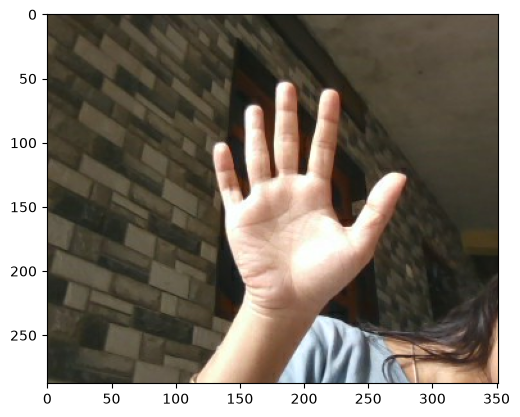

In [18]:
img = cv2.imread("hand.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

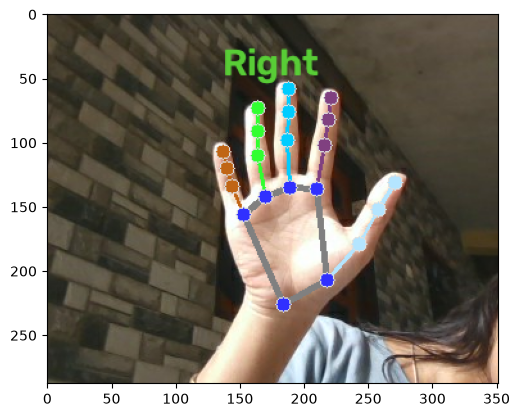

In [16]:
# STEP 1: Import the necessary modules.
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an HandLandmarker object.
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("hand.jpg")

# STEP 4: Detect hand landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the classification result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
plt.imshow(annotated_image)



## Contours

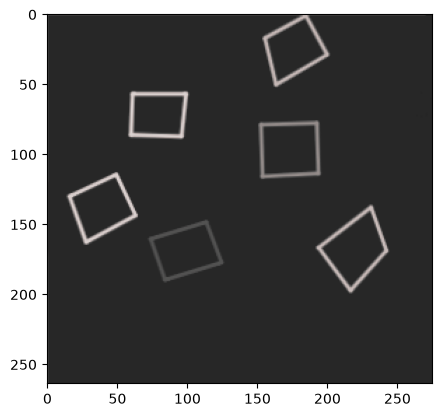

In [30]:
img_boxes = cv2.imread("assets/boxes.png")
img_gray = cv2.cvtColor(img_boxes, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB)
plt.imshow(img_boxes)

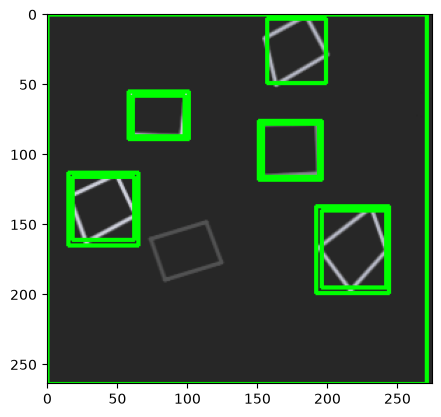

In [35]:
ret, bin_img = cv2.threshold(img_gray, 90, 255, 0)
contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

for index in range(len(contours)):
    # take contour
    cnt=contours[index]
        # find coordinates
    x,y,w,h = cv2.boundingRect(cnt)
        # draw rectangle to original image
    cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(img_rgb)